In [2]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import os
import glob
import pandas as pd
import json
import re
import random

In [14]:
# Folder containing jsonl files

folder_path = "new_bluesky_data"

records = []
for filename in os.listdir(folder_path):
    if filename.lower().endswith(".jsonl"):
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue
                # Adjust these keys if your JSON uses different field names
                text = obj.get('text') 
                date = obj.get('date')
                likes = obj.get('like_count')
                post_id = obj.get('post_id')
                user_id = obj.get('user_id')
                lang = obj.get('langs')

                records.append({'text': text, 'date': date, 'likes': likes, 
                                'post_id': post_id, 'user_id': user_id, 'lang':lang})

# Create DataFrame
df_new_bluesky = pd.DataFrame(records)

# Inspect the first few rows
df_new_bluesky.head()

,text,date,likes,post_id,user_id,lang
0,The Times can run full court pressure campaign...,202403182314,658,92482338,0,[eng]
1,Y’ALL!\n\n“John Barnett was planning to drive ...,202403182142,479,92482339,0,[eng]
2,what I like most about the U.S. press is its u...,202403182023,439,92482340,0,[eng]
3,"9.4M jobs lost, 14.8% unemployment, the econom...",202403181739,1035,92482341,0,[eng]
4,This is a fantastic piece backing up something...,202403180620,143,92482342,0,[eng]


In [15]:
len(df_new_bluesky)

2648

In [16]:
print(df_new_bluesky["text"].iloc[-1])
print("\u72ec\u308a\u8a00\u3092\u30dd\u30c4\u30dd\u30c4\u3068\u545f\u3044\u3066\u3044\u304f")

独り言をポツポツと呟いていく
独り言をポツポツと呟いていく


In [17]:
df_new_bluesky

,text,date,likes,post_id,user_id,lang
0,The Times can run full court pressure campaign...,202403182314,658,92482338,0,[eng]
1,Y’ALL!\n\n“John Barnett was planning to drive ...,202403182142,479,92482339,0,[eng]
2,what I like most about the U.S. press is its u...,202403182023,439,92482340,0,[eng]
3,"9.4M jobs lost, 14.8% unemployment, the econom...",202403181739,1035,92482341,0,[eng]
4,This is a fantastic piece backing up something...,202403180620,143,92482342,0,[eng]
...,...,...,...,...,...,...
2643,少し見ていない間にフォローしてくださってる方が増えている…！！！ありがとうございます…！！\...,202402120205,6,142630019,1000013,[jpn]
2644,はじめまして！\n踊ってみたをしています「とげち」です！\n好きなものは、はりねずみと猗窩座...,202402090822,11,2540478,1000013,[jpn]
2645,らいさきさんを追いかけて来ました！\n私もまだ手探りですが楽しい青空ライフになると良きですね♥️,202402140600,1,168914047,1000014,[jpn]
2646,推しの供給が激しい、、、🤣,202402110450,0,168914048,1000014,[jpn]


In [12]:
AI_LIST = ['Artificial Intelligence',
           'Chat-Gpt',
           'GenAI',
           'Generative AI',
           'gemeni',
           'Open-AI',
           'chatgpt4',
           'Chatbot',
           'magicschool',
           'AI',
           'GAI',
           'magic school']

EDU_LIST = ['Education',
            'Academia',
            'Classroom',
            'Teaching',
            'Teach',
            'research',
            'courses',
            'Teaching tools',
            'Online learning',
            'Distance education',
            'Higher education',
            'k-12 education',
            'Teachers',
            'schools',
            'student',
            'educators',
            'professor',
            'personalized learning',
            'test',
            'quiz',
            'assignment',
            'plagiarism',
            'cheating',
            'instructor',
            'college',
            'lesson',
            'edtech',
            'assessment',
            'early childhood education',
            'academic',
            'k-8 education',
            'lesson plans']

In [19]:
# Convert keyword lists to lowercase for consistent matching
AI_LIST = [kw.lower() for kw in AI_LIST]
EDU_LIST = [kw.lower() for kw in EDU_LIST]

# Function to check if a post contains any AI and any EDU keyword
def is_ai_and_edu_related(text):
    text_lower = text.lower()
    found_ai = any(re.search(r'\b' + re.escape(word) + r'\b', text_lower) for word in AI_LIST)
    found_edu = any(re.search(r'\b' + re.escape(word) + r'\b', text_lower) for word in EDU_LIST)
    return found_ai and found_edu

# Apply filtering
df_new_bluesky['is_ai_edu'] = df_new_bluesky['text'].apply(is_ai_and_edu_related)

# Create filtered DataFrame
df_ai_edu = df_new_bluesky[df_new_bluesky['is_ai_edu']].copy()

df_ai_edu

,text,date,likes,post_id,user_id,lang,is_ai_edu
1931,Legit question: can't AI apps teach themselves...,202309171159,3,22265444,1,[eng],True


In [20]:
df_ai_edu['text']

1931    Legit question: can't AI apps teach themselves...
Name: text, dtype: object

In [21]:
# Reads csv
TWEETS = df_new_bluesky

def get_random_choices(input_list: list) -> list:
    '''Selects a random number of keywords from a given list'''
    chosen = []
    # Random number between 1/2 and full length
    num = random.randint(len(input_list)//2, len(input_list))
    for _ in range(num):
        keyword = random.choice(input_list)
        if keyword not in chosen:
            chosen.append(keyword)
    return chosen

def get_query() -> tuple:
    '''Creates a query using random keywords from both lists'''
    chosen_ai = get_random_choices(AI_LIST)
    chosen_edu = get_random_choices(EDU_LIST)
    return chosen_ai, chosen_edu

def search_tweets(query_ai: list, query_edu: list) -> pd.DataFrame:
    '''Searches the tweets using the query'''
    df = pd.DataFrame(columns=['id','text','Educator','Student','Expert/keynote/researchers'])

    for i in range(len(TWEETS)):
        text = (TWEETS['text'][i]).lower()
        # If the query matches, add it
        if any(ai.lower() in text for ai in query_ai) and any(edu.lower() in text for edu in query_edu):
            df.loc[len(df.index)] = TWEETS.iloc[i]

    return df

def find_percentage(df: pd.DataFrame, query: list) -> tuple:
    '''Finds the percentage of the useful tweets'''
    educator = df[df['Educator'] == 1]
    student = df[df['Student'] == 1]
    expert = df[df['Expert/keynote/researchers'] == 1]

    combined_df = pd.concat([educator, student, expert])
    try:
        percentage = len(combined_df) / len(df)
    except ZeroDivisionError:
        percentage = 0
    info = (percentage, query)

    return info

def main() -> None:
    '''Creates 1000 random queries, returns the top 50'''
    best = []
    for _ in range(1000):
        print(_)
        ai,edu = get_query()
        df = search_tweets(ai, edu)
        combined_query = ai + edu
        tbs = find_percentage(df, combined_query)
        best.append(tbs)
    best.sort(key=lambda x: x[0], reverse=True)
    for i in range(50):
        print('Percentage: ' + str(best[i][0]) + '%', 'Query: ' + str(best[i][1]) + '\n')

if __name__ == '__main__':
    main()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [22]:
import gzip
import os

gz_path = "user_posts.tar.gz"
total_size = os.path.getsize(gz_path)
size    = total_size / 100

lines = []
with gzip.open(gz_path, mode="rb") as f:           # f is a GzipFile
    while f.fileobj.tell() < size:
        chunk = f.readline()                        # returns bytes
        if not chunk:
            break
        line = chunk.decode("utf-8", errors="ignore")  # decode to str
        lines.append(line.rstrip("\n"))

print(f"Read {len(lines)} lines from first 1% of compressed file.")


Read 2274131 lines from first 1% of compressed file.


In [23]:
lines=lines[1:len(lines)-1]

#first data seems not ok!
len(lines)

2274129

In [24]:
import json
import pandas as pd

records = []
for i, line in enumerate(lines):
    line = line.strip()
    if not line:
        # skip empty strings
        continue
    try:
        obj = json.loads(line)
    except json.JSONDecodeError:
        # skip malformed JSON
        print(f"Skipping line {i}: not valid JSON")
        continue

    # pull out just the fields you need
    records.append({
        "post_id":  obj.get("post_id"),
        "user_id":  obj.get("user_id"),
        "date":     obj.get("date"),
        "text":     obj.get("text"),
        "langs":    obj.get("langs"),
    })

# turn into a DataFrame
df = pd.DataFrame(records)

# inspect
df.head()


Skipping line 134: not valid JSON
Skipping line 141: not valid JSON
Skipping line 153: not valid JSON
Skipping line 238: not valid JSON
Skipping line 239: not valid JSON
Skipping line 439: not valid JSON
Skipping line 553: not valid JSON
Skipping line 579: not valid JSON
Skipping line 595: not valid JSON
Skipping line 600: not valid JSON
Skipping line 614: not valid JSON
Skipping line 670: not valid JSON
Skipping line 727: not valid JSON
Skipping line 728: not valid JSON
Skipping line 10020: not valid JSON
Skipping line 10041: not valid JSON
Skipping line 10052: not valid JSON
Skipping line 10065: not valid JSON
Skipping line 10179: not valid JSON
Skipping line 10258: not valid JSON
Skipping line 16845: not valid JSON
Skipping line 16846: not valid JSON
Skipping line 16862: not valid JSON
Skipping line 16866: not valid JSON
Skipping line 17053: not valid JSON
Skipping line 17090: not valid JSON
Skipping line 17124: not valid JSON
Skipping line 17125: not valid JSON
Skipping line 17142:

KeyboardInterrupt: 

In [ ]:
# Select rows where the 'langs' column is exactly ['eng']
mask = df['langs'].apply(lambda x: isinstance(x, list) and x == ['eng'])
df_eng = df[mask]

# Inspect the result
df_eng

,post_id,user_id,date,text,langs
134,185310361,1028680,202309300206,Sidetracked from BSides Canberra to Floriade,[eng]
135,185310362,1028680,202309290016,CTFing at BSides Canberra,[eng]
136,185310363,1028680,202309280146,Listening to some good talks at BSides Canberra,[eng]
137,185310364,1028680,202309200014,Typical workday #cybersecurity,[eng]
138,185310365,1028680,202309170209,Great turn out at the Walk For Yes Canberra,[eng]
...,...,...,...,...,...
2250572,233003602,3907648,202309180116,Chapter 5 of my R19 AU Horus/Seth ENNEAD fanfi...,[eng]
2250573,233003603,3907648,202309291444,Professor Seth/former student Horus #ホルセト Horu...,[eng]
2250574,233003604,3907648,202309301514,"A post-Season 2, Episode 73 #ホルセト Horuseth fan...",[eng]
2250575,233003605,3907648,202310011913,"Put up chapter 4 of ""Less Can Be More"", my Tin...",[eng]


In [ ]:
import re

# Your list of AI-related keywords
AI_LIST = [
    'Artificial Intelligence',
    'Chat-Gpt',
    'GenAI',
    'Generative AI',
    'gemeni',
    'Open-AI',
    'chatgpt4',
    'Chatbot',
    'magicschool',
    'AI',
    'GAI',
    'magic school'
]

# Build a regex pattern that matches any of these terms as whole words (case‐insensitive)
pattern = r'\b(' + '|'.join(re.escape(term) for term in AI_LIST) + r')\b'

# Create a boolean mask: True if text contains any AI keyword
mask_ai = df_eng['text'].str.contains(pattern, case=False, regex=True, na=False)

# Separate out the AI‐related posts
df_ai_related    = df_eng[mask_ai].reset_index(drop=True)
df_not_ai_related = df_eng[~mask_ai].reset_index(drop=True)

# Inspect
print("AI‐related posts:", len(df_ai_related))
print(df_ai_related.head())

print("\nNon‐AI posts:", len(df_not_ai_related))
print(df_not_ai_related.head())


C:\Users\kiara\AppData\Local\Temp\ipykernel_60412\3143433277.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_ai = df_eng['text'].str.contains(pattern, case=False, regex=True, na=False)


AI‐related posts: 7195
     post_id  user_id          date  \
0  221949981   558873  202309120829   
1  147832862    95846  202312292146   
2   64449030    37678  202403161405   
3   64449081    37678  202403151507   
4   64449082    37678  202403151614   

                                                text  langs  
0  breaking: AI companies continue to come up wit...  [eng]  
1  I know that Hamas is literally a creation of t...  [eng]  
2  I think we all have one moment when we get per...  [eng]  
3  Another Elsevier paper with obvious AI-written...  [eng]  
4  Got yelled at on Twitter last time I said anyt...  [eng]  

Non‐AI posts: 1194372
     post_id  user_id          date  \
0  185310361  1028680  202309300206   
1  185310362  1028680  202309290016   
2  185310363  1028680  202309280146   
3  185310364  1028680  202309200014   
4  185310365  1028680  202309170209   

                                              text  langs  
0     Sidetracked from BSides Canberra to Floriade  

In [ ]:
df_ai_related

,post_id,user_id,date,text,langs
0,221949981,558873,202309120829,breaking: AI companies continue to come up wit...,[eng]
1,147832862,95846,202312292146,I know that Hamas is literally a creation of t...,[eng]
2,64449030,37678,202403161405,I think we all have one moment when we get per...,[eng]
3,64449081,37678,202403151507,Another Elsevier paper with obvious AI-written...,[eng]
4,64449082,37678,202403151614,Got yelled at on Twitter last time I said anyt...,[eng]
...,...,...,...,...,...
7190,135503921,145122,202310092019,This might be flying under the radar (so pleas...,[eng]
7191,135504293,145122,202307131356,Some of these are admittedly funny (I'm from C...,[eng]
7192,190901838,1091997,202403071731,Writing is a skill.\nSculpting is a skill.\nDr...,[eng]
7193,190901860,1091997,202403061345,"we warned you that ""AI"" was the new crypto/NFT...",[eng]


In [ ]:
import re
import pandas as pd

# Your DataFrame of posts
# df = pd.read_csv(...)  # or however you have it loaded

# Keyword lists
AI_LIST = [
    'Artificial Intelligence', 'Chat-Gpt', 'GenAI', 'Generative AI',
    'gemeni', 'Open-AI', 'chatgpt4', 'Chatbot', 'magicschool',
    'AI', 'GAI', 'magic school'
]

EDU_LIST = [
    'Education', 'Academia', 'Classroom', 'Teaching', 'Teach', 'research',
    'courses', 'Teaching tools', 'Online learning', 'Distance education',
    'Higher education', 'k-12 education', 'Teachers', 'schools', 'student',
    'educators', 'professor', 'personalized learning', 'test', 'quiz',
    'assignment', 'plagiarism', 'cheating', 'instructor', 'college',
    'lesson', 'edtech', 'assessment', 'early childhood education',
    'academic', 'k-8 education', 'lesson plans'
]

# Build regex patterns (case-insensitive) matching any keyword as a whole word/phrase
pattern_ai  = r'\b(?:' + '|'.join(re.escape(term) for term in AI_LIST)  + r')\b'
pattern_edu = r'\b(?:' + '|'.join(re.escape(term) for term in EDU_LIST) + r')\b'

# Boolean masks
mask_ai  = df_eng['text'].str.contains(pattern_ai,  case=False, regex=True, na=False)
mask_edu = df_eng['text'].str.contains(pattern_edu, case=False, regex=True, na=False)

# Posts containing both an AI term and an Education term
df_ai_edu = df_eng[mask_ai & mask_edu].reset_index(drop=True)

# Inspect results
print(f"Found {len(df_ai_edu)} posts about both AI and Education")
print(df_ai_edu[['text']].head())

# (Optional) Save to CSV
df_ai_edu.to_csv("ai_education_posts.csv", index=False)


Found 254 posts about both AI and Education
                                                text
0  counterpoint: please keep relying on AI for le...
1  for my university's "committee on socially res...
2  AI bros getting heated about plagiarism is pre...
3  A college vending machine showed an error mess...
4  Gen AI evangelists have really dropped all pre...


In [ ]:
import gzip
import os

gz_path = "user_posts.tar.gz"  # change to your .gz path
total_size = os.path.getsize(gz_path)
chunk_size = total_size / 100

for i in range(100):
    start = chunk_size * i
    end   = chunk_size * (i + 1)
    lines = []

    # Re-open the gzip so we start from the beginning each time
    with gzip.open(gz_path, mode="rb") as f:
        # Skip through compressed data until we reach the start offset
        while f.fileobj.tell() < start:
            if not f.readline():
                break

        # Read & decode lines until we hit the end offset
        while f.fileobj.tell() < end:
            chunk = f.readline()
            if not chunk:
                break
            line = chunk.decode("utf-8", errors="ignore").rstrip("\n")
            lines.append(line)

    # Write out this chunk to its own CSV
    out_name = f"user_posts_part_{i+1:03d}.csv"
    with open(out_name, "w", encoding="utf-8") as out:
        for ln in lines:
            out.write(ln + "\n")

    print(f"Chunk {i+1:03d}: wrote {len(lines)} lines to {out_name}")


Chunk 001: wrote 2274131 lines to user_posts_part_001.csv
Chunk 002: wrote 2384323 lines to user_posts_part_002.csv
Chunk 003: wrote 2307523 lines to user_posts_part_003.csv
Chunk 004: wrote 2346990 lines to user_posts_part_004.csv
Chunk 005: wrote 2346823 lines to user_posts_part_005.csv
Chunk 006: wrote 2315189 lines to user_posts_part_006.csv
Chunk 007: wrote 2338421 lines to user_posts_part_007.csv
Chunk 008: wrote 2302997 lines to user_posts_part_008.csv
Chunk 009: wrote 2291872 lines to user_posts_part_009.csv
Chunk 010: wrote 2326122 lines to user_posts_part_010.csv
Chunk 011: wrote 2322687 lines to user_posts_part_011.csv
Chunk 012: wrote 2275748 lines to user_posts_part_012.csv
Chunk 013: wrote 2329738 lines to user_posts_part_013.csv
Chunk 014: wrote 2311329 lines to user_posts_part_014.csv
Chunk 015: wrote 2304505 lines to user_posts_part_015.csv
Chunk 016: wrote 2326947 lines to user_posts_part_016.csv
Chunk 017: wrote 2351242 lines to user_posts_part_017.csv
Chunk 018: wro

In [ ]:
import pandas as pd

# 1) Load the CSV into a DataFrame
df_part1 = pd.read_csv("user_posts_part_001.csv")

# 2) Inspect the first few rows
print(df_part1.head())

ParserError: Error tokenizing data. C error: Expected 20 fields in line 144, saw 21


In [ ]:
import pandas as pd

df = pd.read_csv(
    "user_posts_part_001.csv",
    engine="python",       # more forgiving parser
    sep=",",
    encoding="utf-8",
    on_bad_lines="skip"    # skip malformed lines
)

print(f"Loaded {len(df)} rows × {df.shape[1]} columns")
print(df.head())


Loaded 1544027 rows × 20 columns
  user_posts/                                                                                         0000775 0001761 0001761 00000000000 14727551033 012543  5                                                                                                    ustar   failla                          failla                                                                                                                                                                                                                 user_posts/1662063.jsonl                                                                            0000664 0001761 0001761 00000262572 14722360652 014457  0                                                                                                    ustar   failla                          failla                                                                                                                                                      

In [ ]:
df

,"user_posts/                                                                                         0000775 0001761 0001761 00000000000 14727551033 012543  5                                                                                                    ustar  failla                          failla                                                                                                                                                                                                                 user_posts/1662063.jsonl                                                                            0000664 0001761 0001761 00000262572 14722360652 014457  0                                                                                                    ustar  failla                          failla                                                                                                                                                                                                                 {""post_id"": 128238232","""user_id"": 1662063","""instance"": ""bsky.social""","""date"": 202403101740","""text"": ""\u306a\u3093\u3067\u305d\u3093\u306a\u306b\u4ed6\u4eba\u3092\u30b3\u30f3\u30c8\u30ed\u30fc\u30eb\u3057\u305f\u304c\u308b\u3093\u3067\u3057\u3087\u3046\u306d\u3047""","""langs"": [""jpn""]","""like_count"": 0","""reply_count"": 0","""repost_count"": 0","""reply_to"": null","""replied_author"": null","""thread_root"": null","""thread_root_author"": null","""repost_from"": null","""reposted_author"": null","""quotes"": null","""quoted_author"": null","""labels"": null","""sent_label"": null","""sent_score"": null}"
0,"{""post_id"": 128238233","""user_id"": 1662063","""instance"": ""bsky.social""","""date"": 202403101739","""text"": ""\u304a\u6c17\u6301\u3061\u3068\u30be...","""langs"": [""jpn""]","""like_count"": 0","""reply_count"": 0","""repost_count"": 0","""reply_to"": null","""replied_author"": null","""thread_root"": null","""thread_root_author"": null","""repost_from"": null","""reposted_author"": null","""quotes"": null","""quoted_author"": null","""labels"": null","""sent_label"": null","""sent_score"": null}"
1,"{""post_id"": 128238234","""user_id"": 1662063","""instance"": ""bsky.social""","""date"": 202403101722","""text"": ""\u306f\u3042\u2026\u2026\u6b21\u751f...","""langs"": [""jpn""]","""like_count"": 1","""reply_count"": 0","""repost_count"": 0","""reply_to"": null","""replied_author"": null","""thread_root"": null","""thread_root_author"": null","""repost_from"": null","""reposted_author"": null","""quotes"": null","""quoted_author"": null","""labels"": null","""sent_label"": null","""sent_score"": null}"
2,"{""post_id"": 128238235","""user_id"": 1662063","""instance"": ""bsky.social""","""date"": 202403101722","""text"": ""\u7647\u306b\u969c\u308b\u3088\u3046...","""langs"": [""jpn""]","""like_count"": 0","""reply_count"": 0","""repost_count"": 0","""reply_to"": null","""replied_author"": null","""thread_root"": null","""thread_root_author"": null","""repost_from"": null","""reposted_author"": null","""quotes"": null","""quoted_author"": null","""labels"": null","""sent_label"": null","""sent_score"": null}"
3,"{""post_id"": 128238236","""user_id"": 1662063","""instance"": ""bsky.social""","""date"": 202403101720","""text"": ""\u4eba\u9593\u3081\u3093\u3069\u304f...","""langs"": [""jpn""]","""like_count"": 0","""reply_count"": 0","""repost_count"": 0","""reply_to"": null","""replied_author"": null","""thread_root"": null","""thread_root_author"": null","""repost_from"": null","""reposted_author"": null","""quotes"": null","""quoted_author"": null","""labels"": null","""sent_label"": null","""sent_score"": null}"
4,"{""post_id"": 128238237","""user_id"": 1662063","""instance"": ""bsky.social""","""date"": 202403101720","""text"": ""\u3069\u3063\u3061\u3082\u3069\u3063...","""langs"": [""jpn""]","""like_count"": 0","""reply_count"": 0","""repost_count"": 0","""reply_to"": null","""replied_auth

In [34]:
def list_to_df(lines):

    records = []
    for i, line in enumerate(lines):
        line = line.strip()
        if not line:
            # skip empty strings
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            # skip malformed JSON
            # print(f"Skipping line {i}: not valid JSON")
            continue

        # pull out just the fields you need
        records.append({
            "post_id":  obj.get("post_id"),
            "user_id":  obj.get("user_id"),
            "date":     obj.get("date"),
            "text":     obj.get("text"),
            "langs":    obj.get("langs"),
            "instance": obj.get("instance"),
            "like_count": obj.get("like_count"),
            "repost_count": obj.get("repost_count"),
            "reply_count": obj.get("reply_count"),
            "quote_count": obj.get("quote_count"),
            "label": obj.get("labels"),
            "sentiment": obj.get("sent_label"),
            "sentiment_score": obj.get("sent_score"),
            "reply_to": obj.get("reply_to"),
            "replied_author": obj.get("replied_author"),
            "thread_root": obj.get("thread_root"),
            "thread_root_author": obj.get("thread_root_author"),
            "repost_from": obj.get("repost_from"),
            "reposted_author": obj.get("reposted_author"),
            "quotes": obj.get("quotes"),
            "quoted_author": obj.get("quoted_author")     
        })

    # turn into a DataFrame
    df = pd.DataFrame(records)

    return df

In [36]:
import gzip
import os
import json
import pandas as pd

gz_path = "user_posts.tar.gz"  # change to your .gz path
total_size = os.path.getsize(gz_path)
chunk_size = total_size / 100

for i in range(100):
    start = chunk_size * i
    end   = chunk_size * (i + 1)
    lines = []

    # Re-open the gzip so we start from the beginning each time
    with gzip.open(gz_path, mode="rb") as f:
        # Skip through compressed data until we reach the start offset
        while f.fileobj.tell() < start:
            if not f.readline():
                break

        # Read & decode lines until we hit the end offset
        while f.fileobj.tell() < end:
            chunk = f.readline()
            if not chunk:
                break
            line = chunk.decode("utf-8", errors="ignore").rstrip("\n")
            lines.append(line.rstrip("\n"))
                         
    lines = lines[1:len(lines)-1]
    temp_df = list_to_df(lines)

    # Write out this chunk to its own CSV
    out_name = f"user_posts_part_{i+1:03d}.csv"
    temp_df.to_csv(out_name, index=False, encoding="utf-8")
    print(f"Saved DataFrame to {out_name}")

Saved DataFrame to user_posts_part_001.csv
Saved DataFrame to user_posts_part_002.csv
Saved DataFrame to user_posts_part_003.csv
Saved DataFrame to user_posts_part_004.csv
Saved DataFrame to user_posts_part_005.csv
Saved DataFrame to user_posts_part_006.csv
Saved DataFrame to user_posts_part_007.csv
Saved DataFrame to user_posts_part_008.csv
Saved DataFrame to user_posts_part_009.csv
Saved DataFrame to user_posts_part_010.csv
Saved DataFrame to user_posts_part_011.csv
Saved DataFrame to user_posts_part_012.csv
Saved DataFrame to user_posts_part_013.csv
Saved DataFrame to user_posts_part_014.csv
Saved DataFrame to user_posts_part_015.csv
Saved DataFrame to user_posts_part_016.csv
Saved DataFrame to user_posts_part_017.csv
Saved DataFrame to user_posts_part_018.csv
Saved DataFrame to user_posts_part_019.csv
Saved DataFrame to user_posts_part_020.csv
Saved DataFrame to user_posts_part_021.csv
Saved DataFrame to user_posts_part_022.csv
Saved DataFrame to user_posts_part_023.csv
Saved DataF

In [37]:
import pandas as pd

# 1) Load the CSV into a DataFrame
df_part1 = pd.read_csv("user_posts_part_001.csv")

# 2) Inspect the first few rows
df_part1.head()

,post_id,user_id,date,text,langs,instance,like_count,repost_count,reply_count,quote_count,...,sentiment,sentiment_score,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author
0,128238233,1662063,202403101739,お気持ちとゾーニングについてご教示ましゅまろ飛ばして来た人がURLのリンク載せてたのピクブラ...,['jpn'],bsky.social,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,128238234,1662063,202403101722,はあ……次生まれ変わったら猫ちゃんになりたい 人間やるの疲れるほんと,['jpn'],bsky.social,1,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,128238235,1662063,202403101722,癇に障るような言い方するのもどうかと思う 悪意があるのかないのか知らんけど,['jpn'],bsky.social,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,128238236,1662063,202403101720,人間めんどくせぇ〜〜〜！！！！！,['jpn'],bsky.social,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,128238237,1662063,202403101720,どっちもどっちだと思う ファン同士でしょうもないことやってないで推しのこと見てたらいいの...,['jpn'],bsky.social,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
import pandas as pd
import ast

# Folder where the CSVs live
folder = "."

# List to collect filtered DataFrames
dfs_eng = []

for i in range(1, 101):
    fname = f"user_posts_part_{i:03d}.csv"
    path = os.path.join(folder, fname)
    if not os.path.exists(path):
        print(f"Warning: {fname} not found, skipping.")
        continue

    # 1) Read the CSV
    df = pd.read_csv(path, dtype=str)

    # 2) Parse the 'langs' column from its string repr to a Python list
    df['langs_list'] = df['langs'].apply(lambda s: ast.literal_eval(s) if pd.notna(s) else [])

    # 3) Filter rows where langs == ['eng']
    mask = df['langs_list'].apply(lambda lst: lst == ['eng'])
    df_eng = df[mask].copy()

    # 4) Collect
    dfs_eng.append(df_eng)
    print(f"Processed {fname}: found {len(df_eng)} English‐only posts.")

# 5) Concatenate all English‐only posts
if dfs_eng:
    result = pd.concat(dfs_eng, ignore_index=True)
else:
    result = pd.DataFrame(columns=['post_id','user_id','date','text','langs'])

# 6) Inspect or save
print(f"Total English‐only posts found: {len(result)}")
print(result.head())

# (Optional) save to a single CSV:
result.to_csv("all_eng_posts.csv", index=False)


Processed user_posts_part_001.csv: found 1201567 English‐only posts.
Processed user_posts_part_002.csv: found 1218691 English‐only posts.
Processed user_posts_part_003.csv: found 1219826 English‐only posts.
Processed user_posts_part_004.csv: found 1178798 English‐only posts.
Processed user_posts_part_005.csv: found 1275240 English‐only posts.
Processed user_posts_part_006.csv: found 1231167 English‐only posts.
Processed user_posts_part_007.csv: found 1278688 English‐only posts.
Processed user_posts_part_008.csv: found 1245135 English‐only posts.
Processed user_posts_part_009.csv: found 1301059 English‐only posts.
Processed user_posts_part_010.csv: found 1258197 English‐only posts.
Processed user_posts_part_011.csv: found 1189068 English‐only posts.
Processed user_posts_part_012.csv: found 1196142 English‐only posts.
Processed user_posts_part_013.csv: found 1234827 English‐only posts.
Processed user_posts_part_014.csv: found 1210771 English‐only posts.
Processed user_posts_part_015.csv:

MemoryError: Unable to allocate 20.1 GiB for an array with shape (22, 122544235) and data type object

In [41]:
result

,post_id,user_id,date,text,langs,instance,like_count,repost_count,reply_count,quote_count,...,sentiment_score,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author,langs_list
0,185310361,1028680,202309300206,Sidetracked from BSides Canberra to Floriade,['eng'],info,1,1,0,NaN,...,0.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[eng]
1,185310362,1028680,202309290016,CTFing at BSides Canberra,['eng'],info,0,0,0,NaN,...,0.933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[eng]
2,185310363,1028680,202309280146,Listening to some good talks at BSides Canberra,['eng'],info,0,0,0,NaN,...,0.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[eng]
3,185310364,1028680,202309200014,Typical workday #cybersecurity,['eng'],info,5,0,0,NaN,...,0.638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[eng]
4,185310365,1028680,202309170209,Great turn out at the Walk For Yes Canberra,['eng'],info,40,5,0,NaN,...,0.976,NaN,NaN,NaN,NaN,109202529.0,147.0,NaN,NaN,[eng]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6094117,181245175,167296,202403070316,If this is not done within the next hour it wi...,['eng'],bsky.social,10,15,2,NaN,...,0.643,NaN,NaN,NaN,NaN,5042520.0,46200.0,5042513.0,46200.0,[eng]
6094118,181245176,167296,202403070125,it's funny cuz years ago (way before covid) i ...,['eng'],bsky.social,3,0,0,NaN,...,0.546,138115247.0,167296.0,138115247.0,167296.0,NaN,NaN,NaN,NaN,[eng]
6094119,138115246,167296,202403070109,also can't CSF leaks also cause head pain and ...,['eng'],bsky.social,1,0,1,NaN,...,0.774,138115251.0,30941.0,138115247.0,167296.0,NaN,NaN,NaN,NaN,[eng]
6094120,138115252,167296,202403070058,"that's interesting, i wonder what would've cau...",['eng'],bsky.social,1,0,1,NaN,...,0.681,138115254.0,30941.0,138115247.0,167296.0,NaN,NaN,NaN,NaN,[eng]


In [52]:
eng_posts   = result["langs"].str.strip().eq('[\'eng\']').sum()
eng_posts

6094122

In [5]:
import os
import pandas as pd
import ast

folder        = "."
output_file   = "all_eng_posts.csv"

# Remove existing output file if present
if os.path.exists(output_file):
    os.remove(output_file)

header_written = False

for i in range(1, 101):
    fname = f"user_posts_part_{i:03d}.csv"
    path  = os.path.join(folder, fname)
    if not os.path.exists(path):
        print(f"Warning: {fname} not found, skipping.")
        continue

    print(f"Processing {fname}…")
    for chunk in pd.read_csv(path, dtype=str, chunksize=500000):
        # 1) Parse the 'langs' column into Python lists
        chunk['langs_list'] = chunk['langs'].apply(
            lambda s: ast.literal_eval(s) if pd.notna(s) else []
        )

        # 2) Filter rows where langs == ['eng']
        mask = chunk['langs_list'].apply(lambda lst: lst == ['eng'])
        df_eng = chunk.loc[mask].drop(columns=['langs_list'])  # keep all original columns

        if df_eng.empty:
            continue

        # 3) Append to CSV, writing header only once
        df_eng.to_csv(
            output_file,
            mode='a',
            header=not header_written,
            index=False,
            encoding='utf-8'
        )
        header_written = True

    print(f"  → Appended English‐only posts from {fname}")

print(f"Done! All English posts (with all columns) consolidated in {output_file}")

Processing user_posts_part_001.csv…
  → Appended English‐only posts from user_posts_part_001.csv
Processing user_posts_part_002.csv…
  → Appended English‐only posts from user_posts_part_002.csv
Processing user_posts_part_003.csv…
  → Appended English‐only posts from user_posts_part_003.csv
Processing user_posts_part_004.csv…
  → Appended English‐only posts from user_posts_part_004.csv
Processing user_posts_part_005.csv…
  → Appended English‐only posts from user_posts_part_005.csv
Processing user_posts_part_006.csv…
  → Appended English‐only posts from user_posts_part_006.csv
Processing user_posts_part_007.csv…
  → Appended English‐only posts from user_posts_part_007.csv
Processing user_posts_part_008.csv…
  → Appended English‐only posts from user_posts_part_008.csv
Processing user_posts_part_009.csv…
  → Appended English‐only posts from user_posts_part_009.csv
Processing user_posts_part_010.csv…
  → Appended English‐only posts from user_posts_part_010.csv
Processing user_posts_part_011

In [3]:
import pandas as pd

# 1) Load the CSV into a DataFrame
df_part_eng = pd.read_csv("all_eng_posts.csv")

# 2) Inspect the first few rows
df_part_eng.head()

,post_id,user_id,date,text,langs,instance,like_count,repost_count,reply_count,quote_count,...,sentiment,sentiment_score,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author
0,185310361,1028680,202309300206,Sidetracked from BSides Canberra to Floriade,['eng'],info,1,1,0,NaN,...,1.0,0.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,185310362,1028680,202309290016,CTFing at BSides Canberra,['eng'],info,0,0,0,NaN,...,1.0,0.933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,185310363,1028680,202309280146,Listening to some good talks at BSides Canberra,['eng'],info,0,0,0,NaN,...,2.0,0.950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,185310364,1028680,202309200014,Typical workday #cybersecurity,['eng'],info,5,0,0,NaN,...,1.0,0.638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,185310365,1028680,202309170209,Great turn out at the Walk For Yes Canberra,['eng'],info,40,5,0,NaN,...,2.0,0.976,NaN,NaN,NaN,NaN,109202529.0,147.0,NaN,NaN


In [2]:
import csv
import random

input_path  = "all_eng_posts.csv"
output_path = "all_eng_posts_sampled_10pct.csv"
sample_frac = 0.10

# for reproducibility
random.seed(42)

with open(input_path,  newline="", encoding="utf-8") as fin, \
     open(output_path, "w", newline="", encoding="utf-8") as fout:

    reader = csv.reader(fin)
    writer = csv.writer(fout)

    # 1) Copy header
    header = next(reader)
    writer.writerow(header)

    # 2) Stream rows, sample with probability = sample_frac
    for row in reader:
        if random.random() < sample_frac:
            writer.writerow(row)

print(f"Done! Approx. 10% of rows written to {output_path}")


Done! Approx. 10% of rows written to all_eng_posts_sampled_10pct.csv


In [ ]:
import re
import pandas as pd

# Your keyword lists
AI_LIST  = ['Artificial Intelligence','Chat-Gpt','GenAI','Generative AI',
            'gemeni','Open-AI','chatgpt4','Chatbot','magicschool',
            'AI','GAI','magic school']
EDU_LIST = ['Education','Academia','Classroom','Teaching','Teach','research',
            'courses','Teaching tools','Online learning','Distance education',
            'Higher education','k-12 education','Teachers','schools','student',
            'educators','professor','personalized learning','test','quiz',
            'assignment','plagiarism','cheating','instructor','college',
            'lesson','edtech','assessment','early childhood education',
            'academic','k-8 education','lesson plans']

# Build regex patterns (whole‐word, case‐insensitive)
pattern_ai  = r'\b(?:' + '|'.join(re.escape(w) for w in AI_LIST)  + r')\b'
pattern_edu = r'\b(?:' + '|'.join(re.escape(w) for w in EDU_LIST) + r')\b'

# Container for filtered chunks
frames = []

# Stream through your sampled CSV (or the full one, if you like)
for chunk in pd.read_csv("all_eng_posts_sampled_10pct.csv", dtype=str, chunksize=5000):
    # Boolean masks
    m1 = chunk["text"].str.contains(pattern_ai,  case=False, regex=True, na=False)
    m2 = chunk["text"].str.contains(pattern_edu, case=False, regex=True, na=False)
    # Keep only rows where BOTH are True
    sel = chunk[m1 & m2]
    if not sel.empty:
        frames.append(sel)

# Concatenate all the little pieces into one DataFrame
if frames:
    df_ai_edu_keywords = pd.concat(frames, ignore_index=True)
else:
    df_ai_edu_keywords = pd.DataFrame(columns=chunk.columns)  # empty but same columns

print(f"Found {len(df_ai_edu_keywords)} posts about both AI and Education") 

# 2) Parse the existing date strings (YYYYMMDDHHMM) into datetimes
df_ai_edu_keywords['date'] = pd.to_datetime(df_ai_edu_keywords['date'], format='%Y%m%d%H%M', errors='coerce')

# 3) Reformat to 'YYYY-MM-DD' (year–month–day)
df_ai_edu_keywords['date'] = df_ai_edu_keywords['date'].dt.strftime('%Y-%m-%d')

# 6) Save back out if desired
df.to_csv("df_ai_edu_keywords_formatted.csv", index=False)


df_ai_edu_keywords.to_csv('sample_ai_ edu_keywords.csv', index=False)

df_ai_edu_keywords, df_ai_edu_keywords["date"] # should be in YYYY-MM-DD format now

Found 2707 posts about both AI and Education


,post_id,user_id,date,text,langs,instance,like_count,repost_count,reply_count,quote_count,...,sentiment,sentiment_score,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author
0,64452253,37678,202312130143,counterpoint: please keep relying on AI for le...,['eng'],bsky.social,218,37,5,NaN,...,1.0,0.429,NaN,NaN,NaN,NaN,13469776.0,5749.0,1162710.0,31275.0
1,122663738,353879,202401242209,people are being BLOWN AWAY by the AI promptin...,['eng'],bsky.social,0,0,1,NaN,...,0.0,0.774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,117391892,532107,202308110024,Quick intro: I am philosophy professor. I writ...,['eng'],bsky.social,20,3,2,NaN,...,1.0,0.72,NaN,NaN,NaN,NaN,102455498.0,506932.0,NaN,NaN
3,169380161,1678089,202401312323,What’s ✨neat✨about this is how AI is scraping ...,['eng'],bsky.social,2,0,0,NaN,...,0.0,0.763,628344.0,7332.0,628344.0,7332.0,NaN,NaN,NaN,NaN
4,80004693,435771,202312121510,Looking forward to this student panel on GenAI...,['eng'],bsky.social,5,2,1,NaN,...,2.0,0.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2702,233317320,493576,202403061448,One of the things people don't want to talk ab...,['eng'],bsky.social,627,194,19,NaN,...,0.0,0.645,NaN,NaN,NaN,NaN,2183783.0,76027.0,725520.0,161564.0
2703,42298599,1430288,202403011443,"TIL in the NYT lawsuit, OPEN AI defense says t...",['eng'],bsky.social,407,72,6,NaN,...,1.0,0.697,NaN,NaN,NaN,NaN,5531133.0,5269.0,NaN,NaN
2704,98133628,46432,202312151834,#ChatGPT Has Changed Teaching. Our Readers Tel...,['eng'],bsky.social,0,0,0,NaN,...,1.0,0.849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2705,140311674,65785,202312230450,"RIP to my good friend, who died suddenly when ...",['eng'],bsky.social,867,134,15,NaN,...,0.0,0.915,NaN,NaN,NaN,NaN,2265410.0,39509.0,NaN,NaN


In [29]:
df_ai_edu_keywords["date"]

0       202312130143
1       202401242209
2       202308110024
3       202401312323
4       202312121510
            ...     
2702    202403061448
2703    202403011443
2704    202312151834
2705    202312230450
2706    202311291555
Name: date, Length: 2707, dtype: object

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kiara\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


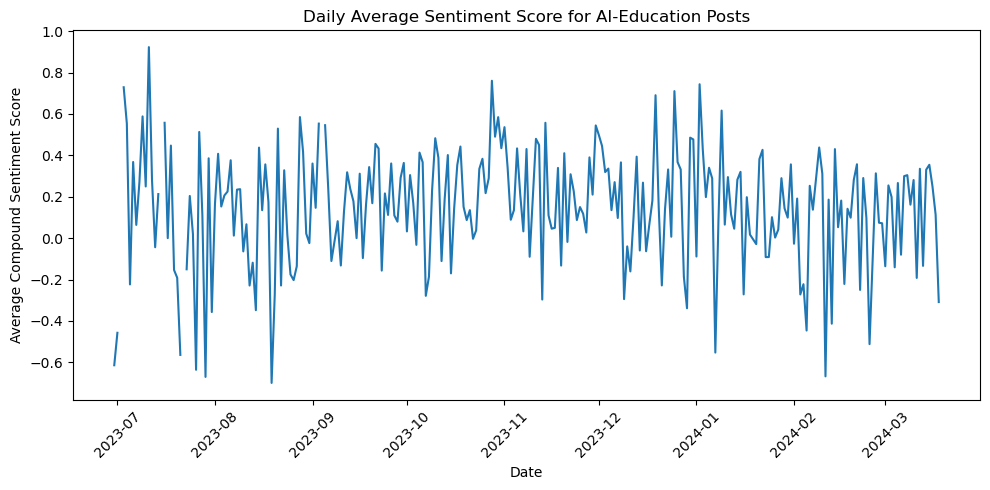

In [27]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Download VADER lexicon if not already available
nltk.download('vader_lexicon')

# Copy the DataFrame
df = df_ai_edu_keywords.copy()

# Parse 'date' column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment_score'] = df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Set date as index and resample by day
df.set_index('date', inplace=True)
daily_sentiment = df['sentiment_score'].resample('D').mean()

# Plot daily average sentiment
plt.figure(figsize=(10, 5))
plt.plot(daily_sentiment.index, daily_sentiment.values)
plt.title('Daily Average Sentiment Score for AI-Education Posts')
plt.xlabel('Date')
plt.ylabel('Average Compound Sentiment Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


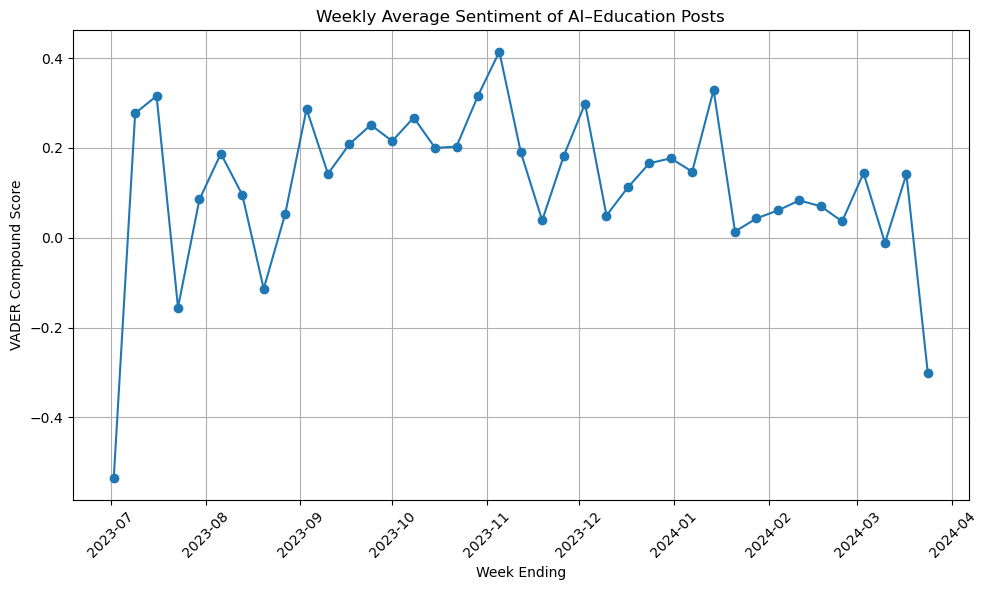

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1) Prepare your DataFrame
df = df_ai_edu_keywords.copy()
df = df.rename(columns={"text": "post"})
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dropna(subset=['date', 'post'], inplace=True)

# 2) Compute VADER sentiment
analyzer = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['post'].apply(lambda txt: analyzer.polarity_scores(txt)['compound'])

# 3) Set the index and resample weekly (Mon–Sun)
df.set_index('date', inplace=True)
weekly = df['sentiment_score'].resample('W').mean().reset_index()
weekly.rename(columns={'sentiment_score': 'avg_sentiment'}, inplace=True)

# 4) Plot weekly average sentiment
plt.figure(figsize=(10, 6))
plt.plot(weekly['date'], weekly['avg_sentiment'], marker='o', linestyle='-')
plt.title('Weekly Average Sentiment of AI–Education Posts')
plt.xlabel('Week Ending')
plt.ylabel('VADER Compound Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
import re
import pandas as pd

# Your keyword lists
AI_LIST  = ['Artificial Intelligence','Chat-Gpt','GenAI','Generative AI',
            'gemeni','Open-AI','chatgpt4','Chatbot','magicschool',
            'AI','GAI','magic school']
EDU_LIST = ['Education','Academia','Classroom','Teaching','Teach','research',
            'courses','Teaching tools','Online learning','Distance education',
            'Higher education','k-12 education','Teachers','schools','student',
            'educators','professor','personalized learning','test','quiz',
            'assignment','plagiarism','cheating','instructor','college',
            'lesson','edtech','assessment','early childhood education',
            'academic','k-8 education','lesson plans']

# Build regex patterns (whole‐word, case‐insensitive)
pattern_ai  = r'\b(?:' + '|'.join(re.escape(w) for w in AI_LIST)  + r')\b'
pattern_edu = r'\b(?:' + '|'.join(re.escape(w) for w in EDU_LIST) + r')\b'

# Container for filtered chunks
frames = []

# Stream through your sampled CSV (or the full one, if you like)
for chunk in pd.read_csv("alex_bluesky_posts_all.csv", dtype=str, chunksize=5000):
    # Boolean masks
    m1 = chunk["text"].str.contains(pattern_ai,  case=False, regex=True, na=False)
    m2 = chunk["text"].str.contains(pattern_edu, case=False, regex=True, na=False)
    # Keep only rows where BOTH are True
    sel = chunk[m1 & m2]
    if not sel.empty:
        frames.append(sel)

# Concatenate all the little pieces into one DataFrame
if frames:
    df_ai_edu_alex = pd.concat(frames, ignore_index=True)
else:
    df_ai_edu_alex = pd.DataFrame(columns=chunk.columns)  # empty but same columns

print(f"Found {len(df_ai_edu_alex)} posts about both AI and Education")

# 2) Parse the ISO timestamps into pandas datetime
df_ai_edu_alex['created_at'] = pd.to_datetime(df_ai_edu_alex['created_at'], utc=True, errors='coerce')

# 3) Reformat to "YYYY-MM-DD"
df_ai_edu_alex['date'] = df_ai_edu_alex['created_at'].dt.strftime('%Y-%m-%d')

# 4) (Optional) Rename column to “date”
# df = df.rename(columns={'created_at':'date'})

# Inspect
df_ai_edu_alex


Found 111319 posts about both AI and Education


,uri,author_name,created_at,author_did,text,reply,link,date
0,at://did:plc:rygblwb6y4ettstfzqcyw3mp/app.bsky...,Matt Reece,2023-06-28 18:43:47.944000+00:00,did:plc:rygblwb6y4ettstfzqcyw3mp,The latest email from a Dean encouraging us to...,NaN,https://bsky.app/profile/mreece.bsky.social/po...,2023-06-28
1,at://did:plc:tbqqvyv6pjjww44glrmycaxl/app.bsky...,Carl T. Bergstrom,2023-06-28 21:09:15.595000+00:00,did:plc:tbqqvyv6pjjww44glrmycaxl,They looked at the performance of 7 different ...,at://did:plc:tbqqvyv6pjjww44glrmycaxl/app.bsky...,https://bsky.app/profile/carlbergstrom.com/pos...,2023-06-28
2,at://did:plc:x3vqyrdzkttyiyfsbclyynmi/app.bsky...,Glenda Sims,2023-06-28 20:28:11.403000+00:00,did:plc:x3vqyrdzkttyiyfsbclyynmi,"""One thing that makes me optimistic...is that ...",NaN,https://bsky.app/profile/gwitch.bsky.social/po...,2023-06-28
3,at://did:plc:nazzzoawtvkr62s25ggrrjvv/app.bsky...,tea,2023-06-29 10:13:49.032000+00:00,did:plc:nazzzoawtvkr62s25ggrrjvv,I don't put much value in my art degree (it on...,NaN,https://bsky.app/profile/steelpeach.bsky.socia...,2023-06-29
4,at://did:plc:slyb6dtlemv6ucoymlcufuan/app.bsky...,Rod Trent,2023-06-29 13:54:06.610000+00:00,did:plc:slyb6dtlemv6ucoymlcufuan,AI Level-Up for Teachers https://rodtrent.com/ock,NaN,https://bsky.app/profile/rodtrent.bsky.social/...,2023-06-29
...,...,...,...,...,...,...,...,...
111314,at://did:plc:qbio45iyqadoe7jfxab56vcb/app.bsky...,Scribaland,2025-03-26 22:05:14.838000+00:00,did:plc:qbio45iyqadoe7jfxab56vcb,#scribaland QUAND LES CHAUVES PRENNENT LE POUV...,NaN,https://bsky.app/profile/scribaland.bsky.socia...,2025-03-26
111315,at://did:plc:rp6bgdpgfxp5oweeic4252id/app.bsky...,Jennifer Musial (she/her),2025-03-26 22:03:31.825000+00:00,did:plc:rp6bgdpgfxp5oweeic4252id,This makes a compelling argument: AI might be ...,NaN,https://bsky.app/profile/jennifermusial.bsky.s...,2025-03-26
111316,at://did:plc:cnupgvdgbdsgswtqf7h55uzi/app.bsky...,Remis Ramos,2025-03-26 22:02:03.277000+00:00,did:plc:cnupgvdgbdsgswtqf7h55uzi,"I don’t use AI-generated images for my talks, ...",NaN,https://bsky.app/profile/remisramos.bsky.socia...,2025-03-26
111317,at://did:plc:ooxkzdb77dw46xjj32xwgu4l/app.bsky...,R. Dubya Slade,2025-03-26 22:00:32.187000+00:00,did:plc:ooxkzdb77dw46xjj32xwgu4l,AI won't eliminate teachers. We're essentially...,at://did:plc:cly4zk3d3a2wrrbb52plfz7f/app.bsky...,https://bsky.app/profile/rdubyaslade.bsky.soci...,2025-03-26


In [32]:
df_ai_edu_keywords

,post_id,user_id,date,text,langs,instance,like_count,repost_count,reply_count,quote_count,...,sentiment,sentiment_score,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author
0,64452253,37678,202312130143,counterpoint: please keep relying on AI for le...,['eng'],bsky.social,218,37,5,NaN,...,1.0,0.429,NaN,NaN,NaN,NaN,13469776.0,5749.0,1162710.0,31275.0
1,122663738,353879,202401242209,people are being BLOWN AWAY by the AI promptin...,['eng'],bsky.social,0,0,1,NaN,...,0.0,0.774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,117391892,532107,202308110024,Quick intro: I am philosophy professor. I writ...,['eng'],bsky.social,20,3,2,NaN,...,1.0,0.72,NaN,NaN,NaN,NaN,102455498.0,506932.0,NaN,NaN
3,169380161,1678089,202401312323,What’s ✨neat✨about this is how AI is scraping ...,['eng'],bsky.social,2,0,0,NaN,...,0.0,0.763,628344.0,7332.0,628344.0,7332.0,NaN,NaN,NaN,NaN
4,80004693,435771,202312121510,Looking forward to this student panel on GenAI...,['eng'],bsky.social,5,2,1,NaN,...,2.0,0.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2702,233317320,493576,202403061448,One of the things people don't want to talk ab...,['eng'],bsky.social,627,194,19,NaN,...,0.0,0.645,NaN,NaN,NaN,NaN,2183783.0,76027.0,725520.0,161564.0
2703,42298599,1430288,202403011443,"TIL in the NYT lawsuit, OPEN AI defense says t...",['eng'],bsky.social,407,72,6,NaN,...,1.0,0.697,NaN,NaN,NaN,NaN,5531133.0,5269.0,NaN,NaN
2704,98133628,46432,202312151834,#ChatGPT Has Changed Teaching. Our Readers Tel...,['eng'],bsky.social,0,0,0,NaN,...,1.0,0.849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2705,140311674,65785,202312230450,"RIP to my good friend, who died suddenly when ...",['eng'],bsky.social,867,134,15,NaN,...,0.0,0.915,NaN,NaN,NaN,NaN,2265410.0,39509.0,NaN,NaN


In [34]:
import pandas as pd

# 1) Load your CSV
df1 = df_ai_edu_keywords

# 2) Parse the existing date strings (YYYYMMDDHHMM) into datetimes
df1['date'] = pd.to_datetime(df_ai_edu_keywords['date'], format='%Y%m%d%H%M', errors='coerce')

# 3) Reformat to 'YYYY-MM-DD' (year–month–day)
df1['date'] = df1['date'].dt.strftime('%Y-%m-%d')

# 5) Inspect the result
df1

,post_id,user_id,date,text,langs,instance,like_count,repost_count,reply_count,quote_count,...,sentiment,sentiment_score,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author
0,64452253,37678,2023-12-13,counterpoint: please keep relying on AI for le...,['eng'],bsky.social,218,37,5,NaN,...,1.0,0.429,NaN,NaN,NaN,NaN,13469776.0,5749.0,1162710.0,31275.0
1,122663738,353879,2024-01-24,people are being BLOWN AWAY by the AI promptin...,['eng'],bsky.social,0,0,1,NaN,...,0.0,0.774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,117391892,532107,2023-08-11,Quick intro: I am philosophy professor. I writ...,['eng'],bsky.social,20,3,2,NaN,...,1.0,0.72,NaN,NaN,NaN,NaN,102455498.0,506932.0,NaN,NaN
3,169380161,1678089,2024-01-31,What’s ✨neat✨about this is how AI is scraping ...,['eng'],bsky.social,2,0,0,NaN,...,0.0,0.763,628344.0,7332.0,628344.0,7332.0,NaN,NaN,NaN,NaN
4,80004693,435771,2023-12-12,Looking forward to this student panel on GenAI...,['eng'],bsky.social,5,2,1,NaN,...,2.0,0.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2702,233317320,493576,2024-03-06,One of the things people don't want to talk ab...,['eng'],bsky.social,627,194,19,NaN,...,0.0,0.645,NaN,NaN,NaN,NaN,2183783.0,76027.0,725520.0,161564.0
2703,42298599,1430288,2024-03-01,"TIL in the NYT lawsuit, OPEN AI defense says t...",['eng'],bsky.social,407,72,6,NaN,...,1.0,0.697,NaN,NaN,NaN,NaN,5531133.0,5269.0,NaN,NaN
2704,98133628,46432,2023-12-15,#ChatGPT Has Changed Teaching. Our Readers Tel...,['eng'],bsky.social,0,0,0,NaN,...,1.0,0.849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2705,140311674,65785,2023-12-23,"RIP to my good friend, who died suddenly when ...",['eng'],bsky.social,867,134,15,NaN,...,0.0,0.915,NaN,NaN,NaN,NaN,2265410.0,39509.0,NaN,NaN


In [38]:
import pandas as pd

# Make sure your date columns are parsed as datetime
df['date']  = pd.to_datetime(df['date'],  errors='coerce')
df1['date'] = pd.to_datetime(df1['date'], errors='coerce')

# Per‐DataFrame ranges
for name, d in [('df', df), ('df1', df1)]:
    lo = d['date'].min()
    hi = d['date'].max()
    print(f"{name}: {lo.date()} → {hi.date()}")

# Overall range across both
all_dates = pd.concat([df['date'], df1['date']])
print(f"Overall: {all_dates.min().date()} → {all_dates.max().date()}")


df: 2023-06-28 → 2025-03-26
df1: 2023-06-30 → 2024-03-18
Overall: 2023-06-28 → 2025-03-26


In [40]:
import pandas as pd

# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Keep only rows on or before 2024-03-18
cutoff = pd.Timestamp('2024-03-18')
df_filtered = df[df['date'] >= cutoff].copy()

# Inspect
print(f"Filtered from {len(df)} → {len(df_filtered)} rows")
df_filtered

Filtered from 111319 → 98341 rows


,uri,author_name,created_at,author_did,text,reply,link,date
12374,at://did:plc:nf37hgymaxgja2nxaxgdmclz/app.bsky...,BBQdotgov,2024-03-18 00:52:19.690000+00:00,did:plc:nf37hgymaxgja2nxaxgdmclz,“Might” carries a LOT of assumptions about the...,at://did:plc:2ndqg2pxeb45bjhjgtc3z7m4/app.bsky...,https://bsky.app/profile/bbqdotgov.bsky.social...,2024-03-18
12375,at://did:plc:m6jn2lx3q3nrybyxbalm3h6n/app.bsky...,Little Gems,2024-03-18 00:40:25.774000+00:00,did:plc:m6jn2lx3q3nrybyxbalm3h6n,How is this what we are using AI for? Being an...,at://did:plc:tbqqvyv6pjjww44glrmycaxl/app.bsky...,https://bsky.app/profile/lettucewrangler.bsky....,2024-03-18
12376,at://did:plc:mqni557xex2iglcxqtzqhnvo/app.bsky...,Prof. Virginia Braun,2024-03-18 00:33:25.908000+00:00,did:plc:mqni557xex2iglcxqtzqhnvo,Something felt 'off' – how AI messed with our...,NaN,https://bsky.app/profile/ginnybraun.bsky.socia...,2024-03-18
12377,at://did:plc:gkwhkppknr3avptzhh4d5rec/app.bsky...,martechnewser,2024-03-18 00:00:41.210000+00:00,did:plc:gkwhkppknr3avptzhh4d5rec,"Apple researchers unveil MM1, a suite of multi...",NaN,https://bsky.app/profile/cheinyeanlim.bsky.soc...,2024-03-18
12378,at://did:plc:qomkdnxrqw3gkbytdxea5z65/app.bsky...,SkynetAndChill.com,2024-03-18 02:30:16.414000+00:00,did:plc:qomkdnxrqw3gkbytdxea5z65,More research seems to be written with the hel...,NaN,https://bsky.app/profile/skynetandchill.com/po...,2024-03-18
...,...,...,...,...,...,...,...,...
111314,at://did:plc:qbio45iyqadoe7jfxab56vcb/app.bsky...,Scribaland,2025-03-26 22:05:14.838000+00:00,did:plc:qbio45iyqadoe7jfxab56vcb,#scribaland QUAND LES CHAUVES PRENNENT LE POUV...,NaN,https://bsky.app/profile/scribaland.bsky.socia...,2025-03-26
111315,at://did:plc:rp6bgdpgfxp5oweeic4252id/app.bsky...,Jennifer Musial (she/her),2025-03-26 22:03:31.825000+00:00,did:plc:rp6bgdpgfxp5oweeic4252id,This makes a compelling argument: AI might be ...,NaN,https://bsky.app/profile/jennifermusial.bsky.s...,2025-03-26
111316,at://did:plc:cnupgvdgbdsgswtqf7h55uzi/app.bsky...,Remis Ramos,2025-03-26 22:02:03.277000+00:00,did:plc:cnupgvdgbdsgswtqf7h55uzi,"I don’t use AI-generated images for my talks, ...",NaN,https://bsky.app/profile/remisramos.bsky.socia...,2025-03-26
111317,at://did:plc:ooxkzdb77dw46xjj32xwgu4l/app.bsky...,R. Dubya Slade,2025-03-26 22:00:32.187000+00:00,did:plc:ooxkzdb77dw46xjj32xwgu4l,AI won't eliminate teachers. We're essentially...,at://did:plc:cly4zk3d3a2wrrbb52plfz7f/app.bsky...,https://bsky.app/profile/rdubyaslade.bsky.soci...,2025-03-26


In [41]:
import pandas as pd

# Ensure 'date' is datetime and set to first of month for grouping
df_filtered['date'] = pd.to_datetime(df_filtered['date'], errors='coerce')
df_filtered['year_month'] = df_filtered['date'].dt.to_period('M')

# Define a sampling function
def sample_month(group, n=200, seed=42):
    k = min(len(group), n)
    return group.sample(n=k, random_state=seed)

# Apply per‐month sampling
sampled = (
    df_filtered
    .groupby('year_month', group_keys=False)
    .apply(lambda g: sample_month(g, n=200, seed=42))
    .drop(columns=['year_month'])
    .reset_index(drop=True)
)

print("Rows per month after sampling:")
print(sampled['date'].dt.to_period('M').value_counts().sort_index())

# `sampled` now contains up to 200 random rows per month
sampled

Rows per month after sampling:
date
2024-03    200
2024-04    200
2024-05    200
2024-06    200
2024-07    200
2024-08    200
2024-09    200
2024-10    200
2024-11    200
2024-12    200
2025-01    200
2025-02    200
2025-03    200
Freq: M, Name: count, dtype: int64


C:\Users\kiara\AppData\Local\Temp\ipykernel_23312\3302387645.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sample_month(g, n=200, seed=42))


,uri,author_name,created_at,author_did,text,reply,link,date
0,at://did:plc:fzup2hayae72i5mckllhhctu/app.bsky...,Melissa Kutner,2024-03-20 13:38:30.206000+00:00,did:plc:fzup2hayae72i5mckllhhctu,I get things like this in my email every few d...,NaN,https://bsky.app/profile/melissannbee.bsky.soc...,2024-03-20
1,at://did:plc:itvwb4pxyizvy724ph3cd4nv/app.bsky...,Jamais Cascio,2024-03-21 17:53:24.216000+00:00,did:plc:itvwb4pxyizvy724ph3cd4nv,His concept of the Singularity still shapes AI...,NaN,https://bsky.app/profile/cascio.bsky.social/po...,2024-03-21
2,at://did:plc:fnfmemff2gnmf3scwj2tpnfm/app.bsky...,🄼🄴🄴🄷🄰🅆🄻 ⭕,2024-03-23 18:00:15.202000+00:00,did:plc:fnfmemff2gnmf3scwj2tpnfm,"Especially in this new age of Ai spam, we need...",at://did:plc:vqtakzi5bityrtbjj4cfan4l/app.bsky...,https://bsky.app/profile/meehawl.bsky.social/p...,2024-03-23
3,at://did:plc:nogtf77xcyjilq52agusqrjx/app.bsky...,José A. Alonso,2024-03-21 12:20:27.801000+00:00,did:plc:nogtf77xcyjilq52agusqrjx,Generative AI and CS education (Increased know...,NaN,https://bsky.app/profile/jalonso.bsky.social/p...,2024-03-21
4,at://did:plc:kgrwlmfbbjwdohza3nmfhdla/app.bsky...,Law360,2024-03-18 20:07:15.140000+00:00,did:plc:kgrwlmfbbjwdohza3nmfhdla,The promise of generative artificial intellige...,at://did:plc:kgrwlmfbbjwdohza3nmfhdla/app.bsky...,https://bsky.app/profile/law360.bsky.social/po...,2024-03-18
...,...,...,...,...,...,...,...,...
2595,at://did:plc:uknx7ask2nrsqe5kszyepqcd/app.bsky...,Queen's University Belfast,2025-03-21 14:46:01.892000+00:00,did:plc:uknx7ask2nrsqe5kszyepqcd,Huge congrats to our Digital Team who won the ...,NaN,https://bsky.app/profile/qubelfastofficial.bsk...,2025-03-21
2596,at://did:plc:vhjxdxl4r3trbicvcsrkclwn/app.bsky...,Florian Wieser,2025-03-08 14:29:42.749000+00:00,did:plc:vhjxdxl4r3trbicvcsrkclwn,... That doesn't undermine academic work and l...,at://did:plc:vhjxdxl4r3trbicvcsrkclwn/app.bsky...,https://bsky.app/profile/wieflo.bsky.social/po...,2025-03-08
2597,at://did:plc:vufvxuig7t3it5acz54ggfpn/app.bsky...,Josh R. Haitch,2025-03-17 04:00:53.719000+00:00,did:plc:vufvxuig7t3it5acz54ggfpn,"And like this ""secret AI hack"" amounts to aski...",at://did:plc:vufvxuig7t3it5acz54ggfpn/app.bsky...,https://bsky.app/profile/realdealjrh.com/post/...,2025-03-17
2598,at://did:plc:iyozhh2nspr66shfjfl2u2nd/app.bsky...,Adam Bessie,2025-03-02 01:18:48.532000+00:00,did:plc:iyozhh2nspr66shfjfl2u2nd,Latest interview on AI doppelgängers and educa...,NaN,https://bsky.app/profile/adambessie.bsky.socia...,2025-03-02


C:\Users\kiara\AppData\Local\Temp\ipykernel_23312\121429452.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


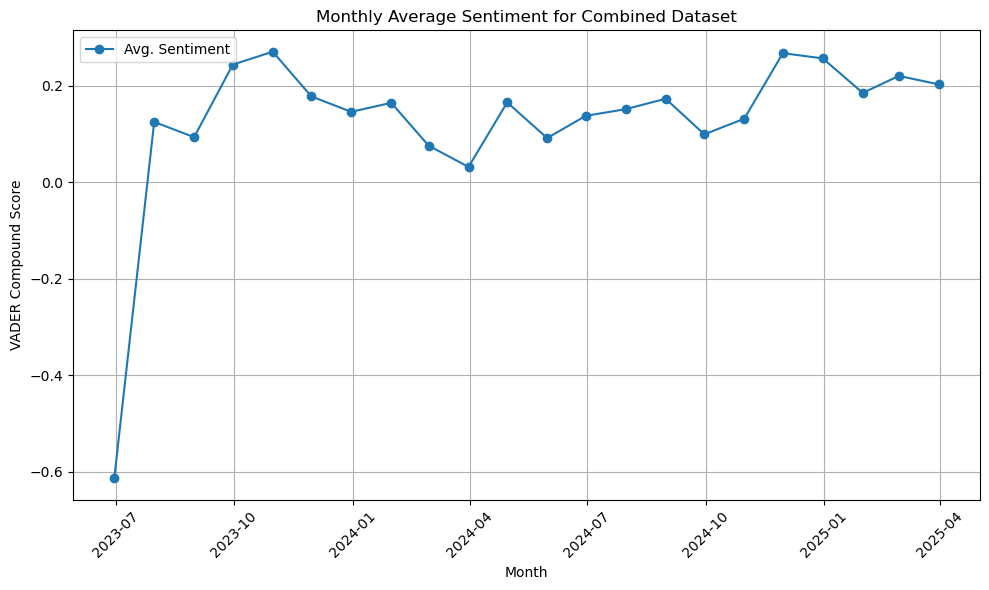

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1) Concatenate sampled and df1
final_df = pd.concat([sampled, df1], ignore_index=True)

# 2) Parse and clean the date column
final_df['date'] = pd.to_datetime(final_df['date'], errors='coerce')
final_df.dropna(subset=['date', 'text'], inplace=True)

# 3) Compute VADER sentiment scores
analyzer = SentimentIntensityAnalyzer()
final_df['sentiment_score'] = final_df['text'].apply(
    lambda txt: analyzer.polarity_scores(txt)['compound']
)

# 4) Resample monthly to get mean sentiment
monthly_sent = (
    final_df
    .set_index('date')['sentiment_score']
    .resample('M')
    .mean()
    .reset_index()
)

# 5) Plot monthly sentiment trend
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_sent['date'],
    monthly_sent['sentiment_score'],
    marker='o', linestyle='-',
    label='Avg. Sentiment'
)
plt.title('Monthly Average Sentiment for Combined Dataset')
plt.xlabel('Month')
plt.ylabel('VADER Compound Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


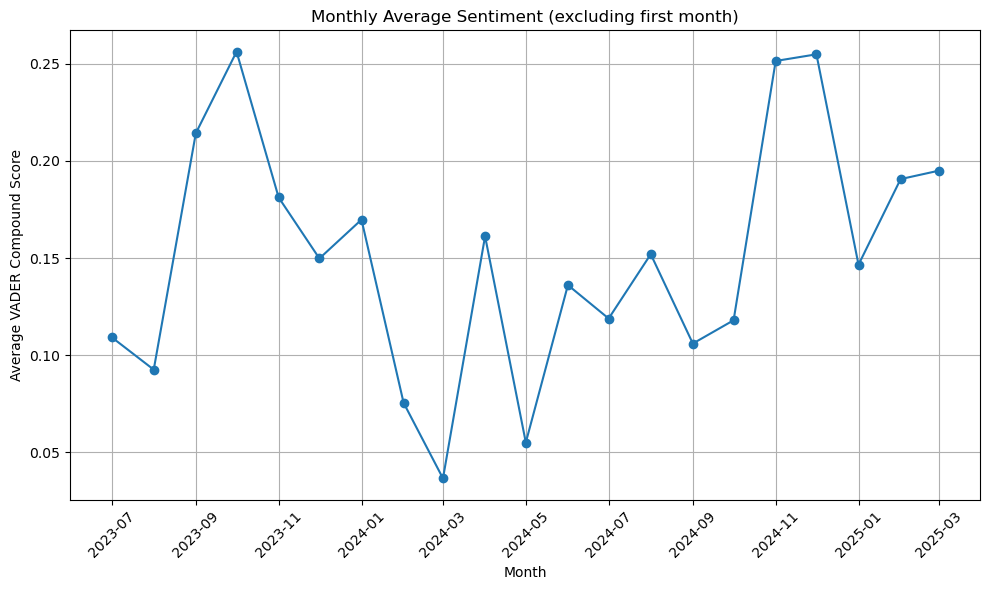

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Ensure VADER lexicon is available
nltk.download('vader_lexicon', quiet=True)

# 1) Concatenate sampled and df1 into final_df
final_df = pd.concat([sampled, df1], ignore_index=True)

# 2) Prepare data
final_df['date'] = pd.to_datetime(final_df['date'], errors='coerce')
final_df.dropna(subset=['date', 'text'], inplace=True)

# 3) Compute sentiment scores for each text
analyzer = SentimentIntensityAnalyzer()
final_df['sentiment_score'] = final_df['text'].apply(lambda txt: analyzer.polarity_scores(str(txt))['compound'])

# 4) Exclude the first month
final_df['year_month'] = final_df['date'].dt.to_period('M')
first_month = final_df['year_month'].min()
df_filtered = final_df[final_df['year_month'] != first_month]

# 5) Calculate monthly average sentiment
monthly_sent = df_filtered.groupby('year_month')['sentiment_score'].mean().reset_index()
monthly_sent['year_month'] = monthly_sent['year_month'].dt.to_timestamp()

# 6) Plot
plt.figure(figsize=(10, 6))
plt.plot(monthly_sent['year_month'], monthly_sent['sentiment_score'], marker='o')
plt.title('Monthly Average Sentiment (excluding first month)')
plt.xlabel('Month')
plt.ylabel('Average VADER Compound Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kiara\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


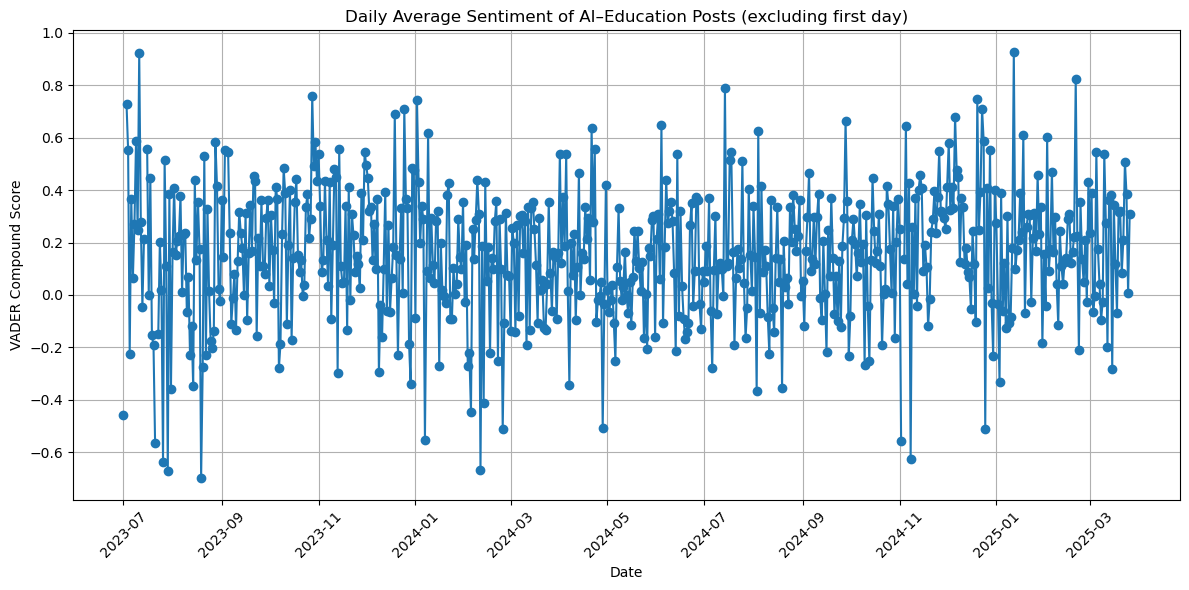

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1) If you haven’t already, download the VADER lexicon once
nltk.download('vader_lexicon')

# 2) Load your data
df = final_df

# 3) Parse your 'date' column—assuming it’s in YYYYMMDDHHMM form
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d%H%M', errors='coerce')
df.dropna(subset=['date', 'text'], inplace=True)

# 4) Compute VADER compound scores
analyzer = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['text'].apply(
    lambda txt: analyzer.polarity_scores(txt)['compound']
)

# 5) Set timestamp index and resample daily
df.set_index('date', inplace=True)
daily = df['sentiment_score'].resample('D').mean().reset_index()

# 6) Exclude the first day entirely
first_day = daily['date'].min()
daily = daily[daily['date'] != first_day]

# 7) Plot daily average sentiment
plt.figure(figsize=(12, 6))
plt.plot(daily['date'], daily['sentiment_score'], marker='o', linestyle='-')
plt.title('Daily Average Sentiment of AI–Education Posts (excluding first day)')
plt.xlabel('Date')
plt.ylabel('VADER Compound Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 1) Load the Excel file
excel_path = "sample_aiedu_keywords_rana_tagged.xlsx"
df = pd.read_excel(excel_path)

# 2) Save as CSV
csv_path = "sample_aiedu_keywords_rana_tagged.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")

# 3) Compute percentage of rows where 'Related' == 1
# Ensure 'Related' is numeric
df['Related'] = pd.to_numeric(df['Related'], errors='coerce')
count_ones = df['Related'].eq(1).sum()
count_zeros = df['Related'].eq(0).sum()

percentage = (count_ones / (count_zeros+count_ones)) * 100

print(f"Saved CSV to: {csv_path}")
print(f"Rows with Related == 1: {count_ones}")
print(f"Percentage with Related == 1: {percentage:.2f}%")
print(count_zeros+count_ones)


Saved CSV to: sample_aiedu_keywords_rana_tagged.csv
Rows with Related == 1: 161
Percentage with Related == 1: 80.90%
199


Working with all the Data

In [1]:
import re
import pandas as pd

# Your keyword lists
AI_LIST  = ['Artificial Intelligence','Chat-Gpt','GenAI','Generative AI',
            'gemeni','Open-AI','chatgpt4','Chatbot','magicschool',
            'AI','GAI','magic school']
EDU_LIST = ['Education','Academia','Classroom','Teaching','Teach','research',
            'courses','Teaching tools','Online learning','Distance education',
            'Higher education','k-12 education','Teachers','schools','student',
            'educators','professor','personalized learning','test','quiz',
            'assignment','plagiarism','cheating','instructor','college',
            'lesson','edtech','assessment','early childhood education',
            'academic','k-8 education','lesson plans']

# Build regex patterns (whole‐word, case‐insensitive)
pattern_ai  = r'\b(?:' + '|'.join(re.escape(w) for w in AI_LIST)  + r')\b'
pattern_edu = r'\b(?:' + '|'.join(re.escape(w) for w in EDU_LIST) + r')\b'

# Container for filtered chunks
frames = []

# Stream through your sampled CSV (or the full one, if you like)
for chunk in pd.read_csv("all_eng_posts.csv", dtype=str, chunksize=10000):
    # Boolean masks
    m1 = chunk["text"].str.contains(pattern_ai,  case=False, regex=True, na=False)
    m2 = chunk["text"].str.contains(pattern_edu, case=False, regex=True, na=False)
    # Keep only rows where BOTH are True
    sel = chunk[m1 & m2]
    if not sel.empty:
        frames.append(sel)

# Concatenate all the little pieces into one DataFrame
if frames:
    df_ai_edu_keywords = pd.concat(frames, ignore_index=True)
else:
    df_ai_edu_keywords = pd.DataFrame(columns=chunk.columns)  # empty but same columns

print(f"Found {len(df_ai_edu_keywords)} posts about both AI and Education") 

# 2) Parse the existing date strings (YYYYMMDDHHMM) into datetimes
df_ai_edu_keywords['date'] = pd.to_datetime(df_ai_edu_keywords['date'], format='%Y%m%d%H%M', errors='coerce')

# 3) Reformat to 'YYYY-MM-DD' (year–month–day)
df_ai_edu_keywords['date'] = df_ai_edu_keywords['date'].dt.strftime('%Y-%m-%d')

df_ai_edu_keywords.to_csv('ai_ edu_keywords_all.csv', index=False)

df_ai_edu_keywords, df_ai_edu_keywords["date"] # should be in YYYY-MM-DD format now

Found 27000 posts about both AI and Education


(         post_id user_id        date  \
 0       64452253   37678  2023-12-13   
 1       64452562   37678  2023-12-04   
 2      168456686  401436  2024-01-03   
 3      233365466  292389  2024-02-26   
 4      233367539  292389  2023-10-06   
 ...          ...     ...         ...   
 26995  140311674   65785  2023-12-23   
 26996  140312360   65785  2023-11-29   
 26997  140312897   65785  2023-11-08   
 26998  140313292   65785  2023-10-30   
 26999  140313442   65785  2023-10-24   
 
                                                     text    langs  \
 0      counterpoint: please keep relying on AI for le...  ['eng']   
 1      for my university's "committee on socially res...  ['eng']   
 2      AI bros getting heated about plagiarism is pre...  ['eng']   
 3      A college vending machine showed an error mess...  ['eng']   
 4      Gen AI evangelists have really dropped all pre...  ['eng']   
 ...                                                  ...      ...   
 26995  RIP to m

In [8]:
df_ai_edu_keywords = pd.read_csv("ai_ edu_keywords_all.csv", dtype=str)
df_ai_edu_keywords

,post_id,user_id,date,text,langs,instance,like_count,repost_count,reply_count,quote_count,...,sentiment,sentiment_score,reply_to,replied_author,thread_root,thread_root_author,repost_from,reposted_author,quotes,quoted_author
0,64452253,37678,2023-12-13,counterpoint: please keep relying on AI for le...,['eng'],bsky.social,218,37,5,NaN,...,1.0,0.429,NaN,NaN,NaN,NaN,13469776.0,5749.0,1162710.0,31275.0
1,64452562,37678,2023-12-04,"for my university's ""committee on socially res...",['eng'],bsky.social,25,6,1,NaN,...,1.0,0.633,NaN,NaN,NaN,NaN,40619641.0,148057.0,NaN,NaN
2,168456686,401436,2024-01-03,AI bros getting heated about plagiarism is pre...,['eng'],bsky.social,1859,344,18,NaN,...,0.0,0.455,NaN,NaN,NaN,NaN,854266.0,5309.0,NaN,NaN
3,233365466,292389,2024-02-26,A college vending machine showed an error mess...,['eng'],bsky.social,96,69,10,NaN,...,0.0,0.772,NaN,NaN,NaN,NaN,579129.0,81413.0,NaN,NaN
4,233367539,292389,2023-10-06,Gen AI evangelists have really dropped all pre...,['eng'],bsky.social,210,88,9,NaN,...,0.0,0.83,NaN,NaN,NaN,NaN,953377.0,76027.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26995,140311674,65785,2023-12-23,"RIP to my good friend, who died suddenly when ...",['eng'],bsky.social,867,134,15,NaN,...,0.0,0.915,NaN,NaN,NaN,NaN,2265410.0,39509.0,NaN,NaN
26996,140312360,65785,2023-11-29,"More like, unfortunately, the best use-case fo...",['eng'],bsky.social,0,1,0,NaN,...,0.0,0.697,140312361.0,24112.0,275672.0,24112.0,NaN,NaN,NaN,NaN
26997,140312897,65785,2023-11-08,For (boring and unsexy) things that machines e...,['eng'],bsky.social,3,0,0,NaN,...,2.0,0.617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26998,140313292,65785,2023-10-30,a voluntary code of conduct because if there i...,['eng'],bsky.social,480,99,9,NaN,...,2.0,0.57,NaN,NaN,NaN,NaN,732338.0,4133.0,732339.0,49515.0


In [7]:
df_ai_edu_alex

,uri,author_name,created_at,author_did,text,reply,link,date
0,at://did:plc:rygblwb6y4ettstfzqcyw3mp/app.bsky...,Matt Reece,2023-06-28 18:43:47.944000+00:00,did:plc:rygblwb6y4ettstfzqcyw3mp,The latest email from a Dean encouraging us to...,NaN,https://bsky.app/profile/mreece.bsky.social/po...,2023-06-28
1,at://did:plc:tbqqvyv6pjjww44glrmycaxl/app.bsky...,Carl T. Bergstrom,2023-06-28 21:09:15.595000+00:00,did:plc:tbqqvyv6pjjww44glrmycaxl,They looked at the performance of 7 different ...,at://did:plc:tbqqvyv6pjjww44glrmycaxl/app.bsky...,https://bsky.app/profile/carlbergstrom.com/pos...,2023-06-28
2,at://did:plc:x3vqyrdzkttyiyfsbclyynmi/app.bsky...,Glenda Sims,2023-06-28 20:28:11.403000+00:00,did:plc:x3vqyrdzkttyiyfsbclyynmi,"""One thing that makes me optimistic...is that ...",NaN,https://bsky.app/profile/gwitch.bsky.social/po...,2023-06-28
3,at://did:plc:nazzzoawtvkr62s25ggrrjvv/app.bsky...,tea,2023-06-29 10:13:49.032000+00:00,did:plc:nazzzoawtvkr62s25ggrrjvv,I don't put much value in my art degree (it on...,NaN,https://bsky.app/profile/steelpeach.bsky.socia...,2023-06-29
4,at://did:plc:slyb6dtlemv6ucoymlcufuan/app.bsky...,Rod Trent,2023-06-29 13:54:06.610000+00:00,did:plc:slyb6dtlemv6ucoymlcufuan,AI Level-Up for Teachers https://rodtrent.com/ock,NaN,https://bsky.app/profile/rodtrent.bsky.social/...,2023-06-29
...,...,...,...,...,...,...,...,...
111314,at://did:plc:qbio45iyqadoe7jfxab56vcb/app.bsky...,Scribaland,2025-03-26 22:05:14.838000+00:00,did:plc:qbio45iyqadoe7jfxab56vcb,#scribaland QUAND LES CHAUVES PRENNENT LE POUV...,NaN,https://bsky.app/profile/scribaland.bsky.socia...,2025-03-26
111315,at://did:plc:rp6bgdpgfxp5oweeic4252id/app.bsky...,Jennifer Musial (she/her),2025-03-26 22:03:31.825000+00:00,did:plc:rp6bgdpgfxp5oweeic4252id,This makes a compelling argument: AI might be ...,NaN,https://bsky.app/profile/jennifermusial.bsky.s...,2025-03-26
111316,at://did:plc:cnupgvdgbdsgswtqf7h55uzi/app.bsky...,Remis Ramos,2025-03-26 22:02:03.277000+00:00,did:plc:cnupgvdgbdsgswtqf7h55uzi,"I don’t use AI-generated images for my talks, ...",NaN,https://bsky.app/profile/remisramos.bsky.socia...,2025-03-26
111317,at://did:plc:ooxkzdb77dw46xjj32xwgu4l/app.bsky...,R. Dubya Slade,2025-03-26 22:00:32.187000+00:00,did:plc:ooxkzdb77dw46xjj32xwgu4l,AI won't eliminate teachers. We're essentially...,at://did:plc:cly4zk3d3a2wrrbb52plfz7f/app.bsky...,https://bsky.app/profile/rdubyaslade.bsky.soci...,2025-03-26


In [9]:

common_columns = df_ai_edu_keywords.columns.intersection(df_ai_edu_alex.columns)

# 2) Keep only the common columns in both DataFrames
df_ai_edu_keywords_common = df_ai_edu_keywords[common_columns]
df_ai_edu_alex_common = df_ai_edu_alex[common_columns]

# 3) Concatenate the two DataFrames along rows (axis=0)
df_combined = pd.concat([df_ai_edu_keywords_common, df_ai_edu_alex_common], axis=0, ignore_index=True)

# Show the combined DataFrame
df_combined


,date,text
0,2023-12-13,counterpoint: please keep relying on AI for le...
1,2023-12-04,"for my university's ""committee on socially res..."
2,2024-01-03,AI bros getting heated about plagiarism is pre...
3,2024-02-26,A college vending machine showed an error mess...
4,2023-10-06,Gen AI evangelists have really dropped all pre...
...,...,...
138314,2025-03-26,#scribaland QUAND LES CHAUVES PRENNENT LE POUV...
138315,2025-03-26,This makes a compelling argument: AI might be ...
138316,2025-03-26,"I don’t use AI-generated images for my talks, ..."
138317,2025-03-26,AI won't eliminate teachers. We're essentially...


In [11]:
df_combined_no_duplicates = df_combined.drop_duplicates(keep='first')

df_combined_no_duplicates.to_csv('ai_ edu_keywords_all.csv', index=False)
df_combined_no_duplicates

,date,text
0,2023-12-13,counterpoint: please keep relying on AI for le...
1,2023-12-04,"for my university's ""committee on socially res..."
2,2024-01-03,AI bros getting heated about plagiarism is pre...
3,2024-02-26,A college vending machine showed an error mess...
4,2023-10-06,Gen AI evangelists have really dropped all pre...
...,...,...
138314,2025-03-26,#scribaland QUAND LES CHAUVES PRENNENT LE POUV...
138315,2025-03-26,This makes a compelling argument: AI might be ...
138316,2025-03-26,"I don’t use AI-generated images for my talks, ..."
138317,2025-03-26,AI won't eliminate teachers. We're essentially...


C:\Users\kiara\AppData\Local\Temp\ipykernel_25160\1913593510.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['date'] = pd.to_datetime(final_df['date'], errors='coerce')
C:\Users\kiara\AppData\Local\Temp\ipykernel_25160\1913593510.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.dropna(subset=['date', 'text'], inplace=True)
C:\Users\kiara\AppData\Local\Temp\ipykernel_25160\1913593510.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



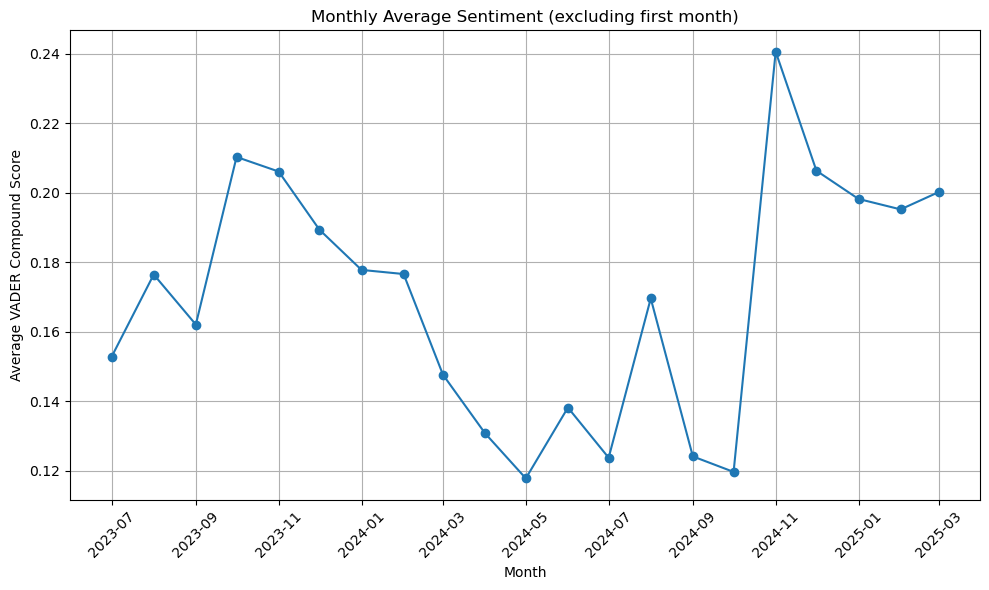

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Ensure VADER lexicon is available
nltk.download('vader_lexicon', quiet=True)

# 1) Concatenate sampled and df1 into final_df
final_df = df_combined_no_duplicates

# 2) Prepare data
final_df['date'] = pd.to_datetime(final_df['date'], errors='coerce')
final_df.dropna(subset=['date', 'text'], inplace=True)

# 3) Compute sentiment scores for each text
analyzer = SentimentIntensityAnalyzer()
final_df['sentiment_score'] = final_df['text'].apply(lambda txt: analyzer.polarity_scores(str(txt))['compound'])

# 4) Exclude the first month
final_df['year_month'] = final_df['date'].dt.to_period('M')
first_month = final_df['year_month'].min()
df_filtered = final_df[final_df['year_month'] != first_month]

# 5) Calculate monthly average sentiment
monthly_sent = df_filtered.groupby('year_month')['sentiment_score'].mean().reset_index()
monthly_sent['year_month'] = monthly_sent['year_month'].dt.to_timestamp()

# 6) Plot
plt.figure(figsize=(10, 6))
plt.plot(monthly_sent['year_month'], monthly_sent['sentiment_score'], marker='o')
plt.title('Monthly Average Sentiment (excluding first month)')
plt.xlabel('Month')
plt.ylabel('Average VADER Compound Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\kiara\AppData\Local\Temp\ipykernel_25160\1045018900.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_no_duplicates['date'] = pd.to_datetime(df_combined_no_duplicates['date'], errors='coerce')
C:\Users\kiara\AppData\Local\Temp\ipykernel_25160\1045018900.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_no_duplicates['sentiment_score'] = df_combined_no_duplicates['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])


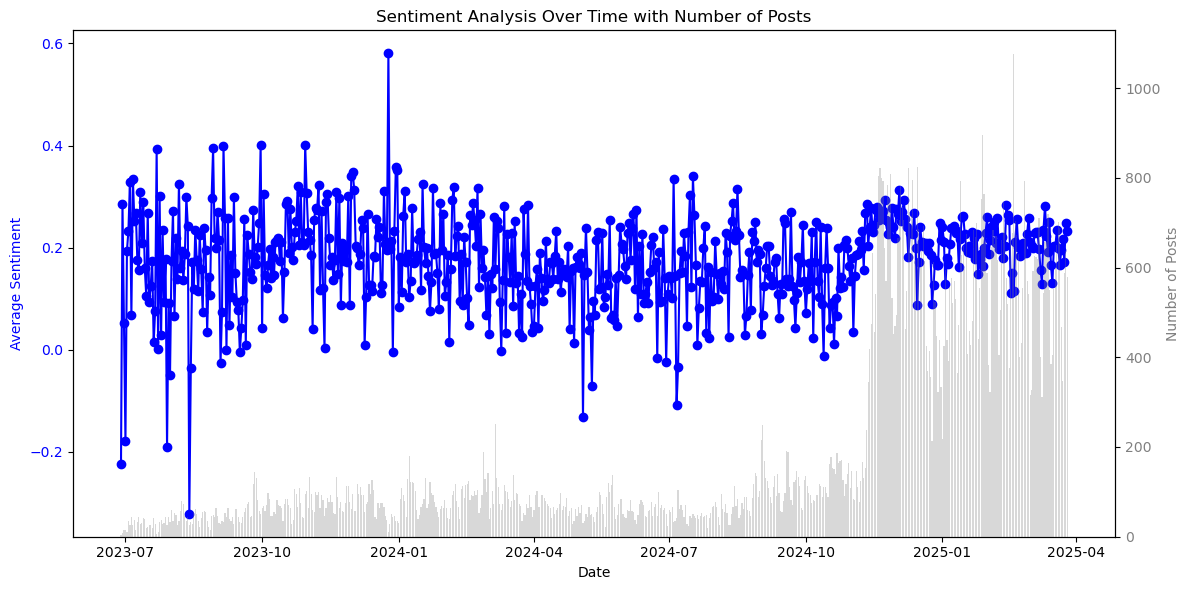

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1) Assuming df_combined_no_duplicates is already loaded

# Ensure the 'date' column is in datetime format
df_combined_no_duplicates['date'] = pd.to_datetime(df_combined_no_duplicates['date'], errors='coerce')

# 2) Perform sentiment analysis using VADER
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis and get the compound score for each post
df_combined_no_duplicates['sentiment_score'] = df_combined_no_duplicates['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# 3) Aggregate sentiments by date and count the number of posts per date
sentiment_by_date = df_combined_no_duplicates.groupby(df_combined_no_duplicates['date'].dt.date).agg(
    sentiment_mean=('sentiment_score', 'mean'),
    post_count=('sentiment_score', 'count')
).reset_index()

# 4) Plot the sentiment scores along with post counts
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot sentiment scores (average per day)
ax1.plot(sentiment_by_date['date'], sentiment_by_date['sentiment_mean'], color='b', label='Average Sentiment', marker='o')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Sentiment', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot post counts (on a secondary axis)
ax2 = ax1.twinx()  
ax2.bar(sentiment_by_date['date'], sentiment_by_date['post_count'], color='gray', alpha=0.3, label='Number of Posts')
ax2.set_ylabel('Number of Posts', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Title and layout
plt.title('Sentiment Analysis Over Time with Number of Posts')
fig.tight_layout()  # Adjust layout to prevent clipping
plt.xticks(rotation=45)
plt.show()


C:\Users\kiara\AppData\Local\Temp\ipykernel_25160\724225992.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_no_duplicates['date'] = pd.to_datetime(df_combined_no_duplicates['date'], errors='coerce')
C:\Users\kiara\AppData\Local\Temp\ipykernel_25160\724225992.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_no_duplicates['sentiment_score'] = df_combined_no_duplicates['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])


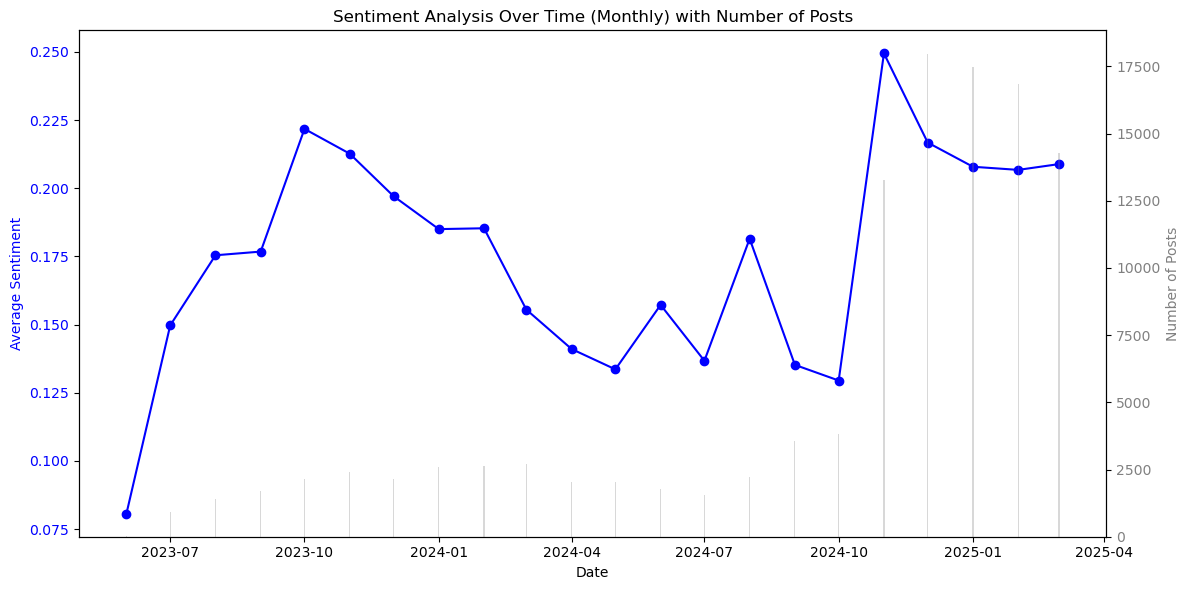

In [10]:
# Ensure the 'date' column is in datetime format
df_combined_no_duplicates['date'] = pd.to_datetime(df_combined_no_duplicates['date'], errors='coerce')

# 2) Perform sentiment analysis using VADER
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis and get the compound score for each post
df_combined_no_duplicates['sentiment_score'] = df_combined_no_duplicates['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# 3) Aggregate sentiments by month and year, and count the number of posts per month
sentiment_by_month = df_combined_no_duplicates.groupby(df_combined_no_duplicates['date'].dt.to_period('M')).agg(
    sentiment_mean=('sentiment_score', 'mean'),
    post_count=('sentiment_score', 'count')
).reset_index()

# Convert the Period to a datetime object for plotting
sentiment_by_month['date'] = sentiment_by_month['date'].dt.to_timestamp()

# 4) Plot the sentiment scores along with post counts
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot sentiment scores (average per month)
ax1.plot(sentiment_by_month['date'], sentiment_by_month['sentiment_mean'], color='b', label='Average Sentiment', marker='o')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Sentiment', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot post counts (on a secondary axis)
ax2 = ax1.twinx()  
ax2.bar(sentiment_by_month['date'], sentiment_by_month['post_count'], color='gray', alpha=0.3, label='Number of Posts')
ax2.set_ylabel('Number of Posts', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Title and layout
plt.title('Sentiment Analysis Over Time (Monthly) with Number of Posts')
fig.tight_layout()  # Adjust layout to prevent clipping
plt.xticks(rotation=45)
plt.show()
